<a href="https://colab.research.google.com/github/AlyW8/Data-Science/blob/main/AlysWangUnit8Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Your file on your github needs to be a a .ipynb file with the first four letters of one first name, the first four letters of one last name, and U6proj.

Ex1.

A student named Avy Aguacate Avocado Palta will submit a file named "Avy_AvocU8proj.ipynb", since she normally just goes by Avy, and, when pressed, reports Avocado as her last name. The " _ " after "Avy" serves as the fourth "letter" in her first name.

Ex2.

Army Armadillo will submit a file named "ArmyArmaU8proj.ipynb"

# Unit 8 Project: Writing a BARTical

**Task**:

Two parts:

1. Propose a data set that's compatible with a pymc_bart model. I must approve your submission before you move on to part 2.

2. Create, analyze, and present BART model, using pymc_bart within the colab environment, on a data set of your choice, with the following conditions:
  - your final model must have more than 2 predictors. The intercept term doesn't count as a predictor here (even though technically it is)
  - You must argue why your variable selection is justified. You may use either a theoretical or numerical argument. Additionally, you must comment on any potential interactions between your predictor variables.



Guidlines:

- Your data or your model type must be different from any project you've previously done.

- You are allowed to copy and paste any code from the notes, including my answer key (AK), without any reference or citations. Same goes for the course textbook, BAP3.

- This is an individual project. It is fine if you model the same process as a peer, but your raw data **must** be substantially different. "Substantially different" means that I, your instructor, arbitrarily think your data sets are different enough.

- Do not look at other student's code/jupyter notebooks. Copying, or copying and pasting, other students code will result in a failing grade. Also, I will tell all the other teachers I know that you cheated.

- If you want to know what another student did, ask them--any verbal communication about a project is allowed and encouraged. If you want to see a graphic they made, ask them to sketch a picture of it for you by hand.

- Any handwritten communication is also allowed and encouraged, so long as all parties are in the same physical location together. Example: you may sketch out a piece of code while verbally explaining to someone what you did. Do NOT: hand write the code for your entire project, take a picture, and send it to everyone in the course.

- If you use someone's code from outside this course (like from the internet, an AI, or your parent), you must ask me if it is ok, and you must cite them in your work. I don't care all they did was to click your space bar one more time: you tell me, and you cite their contribution. You don't need to tell me about or cite verbal or handwritten communication though.

- You may use a more complicated model--like something from further along in the course--IF I give you permission.

- If you are unsure whether or not something is ok or allowed: ASK BEFORE YOU DO IT.

Faliure to adhere to these guidlines will result in a failing grade.

Tips:

- Try to pick something that you care about, have knowledge of, experience with, or that you find interesting/cool.

- Gather data *before* picking a model or likelihood.

-  Use your best idea now; maybe you can look at the context you used in the previous project, and gather different data from it.

- Choose a data set with lots of columns, and lots of potential interactions between variables. It'll be more fun, and will make model/variable selection more relevant.

- Comment heavily, and explain your steps and thought process with text blocks. This is not only requried, it'll also help you understand what you're doing and what you want to do.

- Its ok to pick a data set for which you don't qute understand the context--so long as you think the context is cool.


# Intro

I'm using the counties data set, measuring he food environment index. While I have no idea what that acually is, Gemini says it measures "A county's access to health, affordable food" and that it takes into account both income and proximity to healthy foods.  

In [ ]:
!pip install pymc-bart
!pip install preliz
import preliz as pz
import pymc_bart as pmb
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc_bart as pmb
import seaborn as sns
import graphviz as gv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.9/513.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.2 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0


In [ ]:
counties = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/counties.csv')

In [ ]:
cont = counties[["health/Food Environment Index", "latitude (deg)", "noaa/prcp", "noaa/temp-oct", "population/2016", "land_area (km^2)", "poverty-rate", "avg_income" ]]
cont["pop_density"] = cont["population/2016"] / cont["land_area (km^2)"]
cont.drop(columns = ["population/2016", "land_area (km^2)"], inplace = True)

/tmp/ipykernel_22434/62514698.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cont["pop_density"] = cont["population/2016"] / cont["land_area (km^2)"]
/tmp/ipykernel_22434/62514698.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cont.drop(columns = ["population/2016", "land_area (km^2)"], inplace = True)


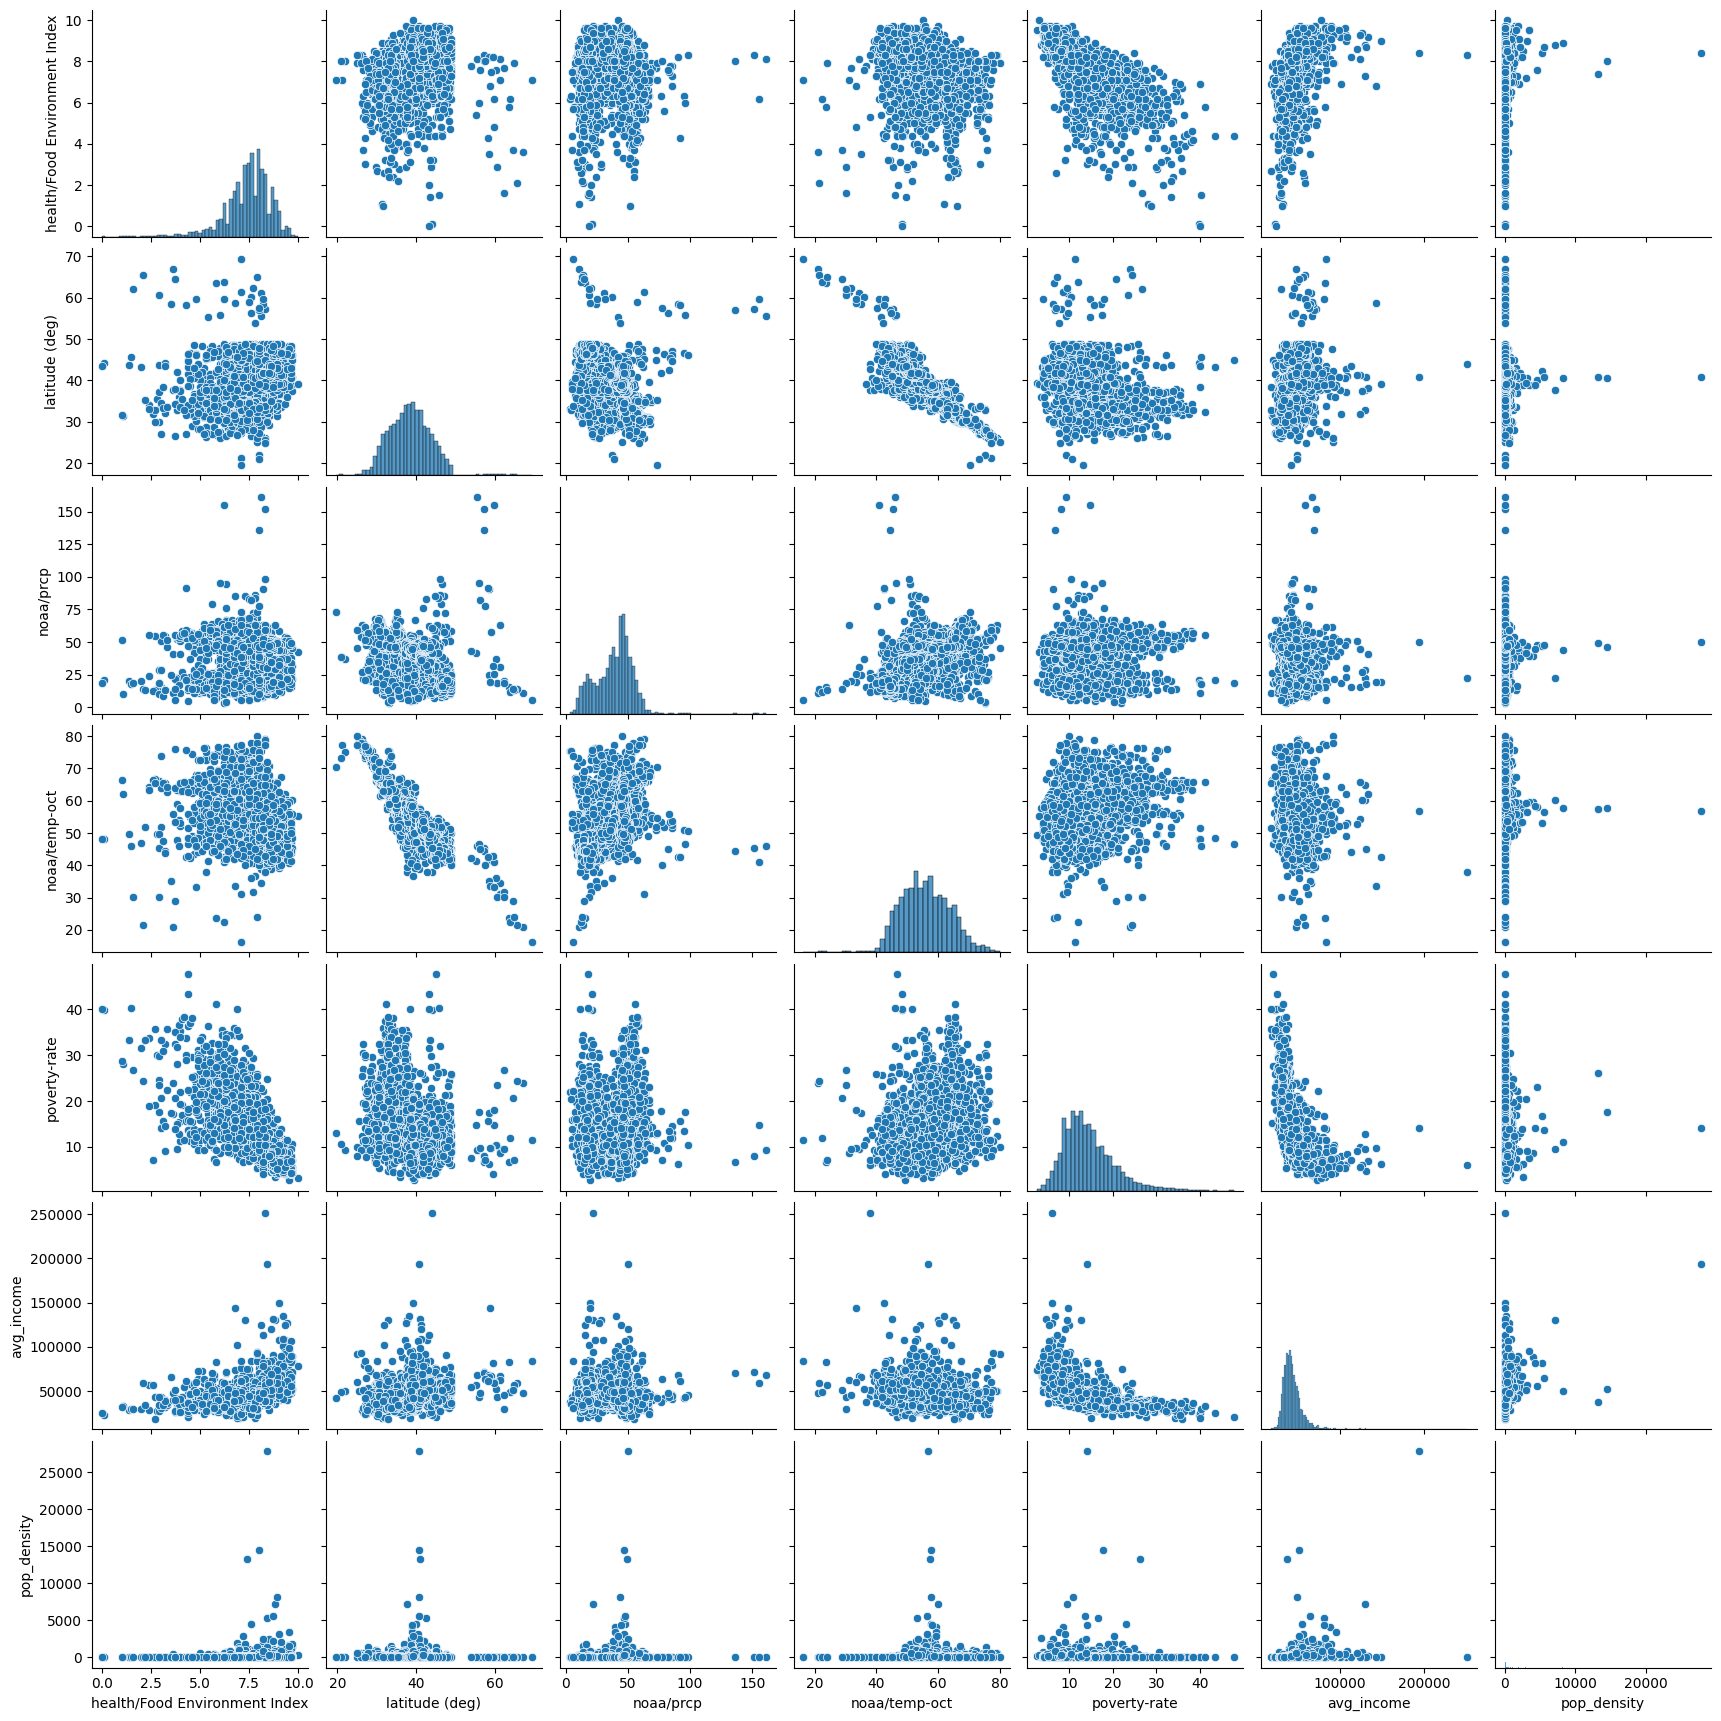

In [ ]:
sns.pairplot(cont)

Latitude, precipitation, and Oct. temperature don't seem to have any strong correlation with Food Environment Index, so I'm dropping them. Poverty and income, things that have more to do with commerce, seem to have stronger correlations, so I'll try variables that might have to do with those things. And obesity, because why not.

In [ ]:
cont = cont.drop(columns = ["latitude (deg)", "noaa/prcp", "noaa/temp-oct"])
cont[["obesity", "employed","food_costs","wholesale","transpo","food_services"]] = counties[["health/% Adults with Obesity", "bls/2016/employed", "cost-of-living/food_costs", "industry/Wholesale trade/employees","industry/Transportation and warehousing/employees", "industry/Accommodation and food services/employees"]]

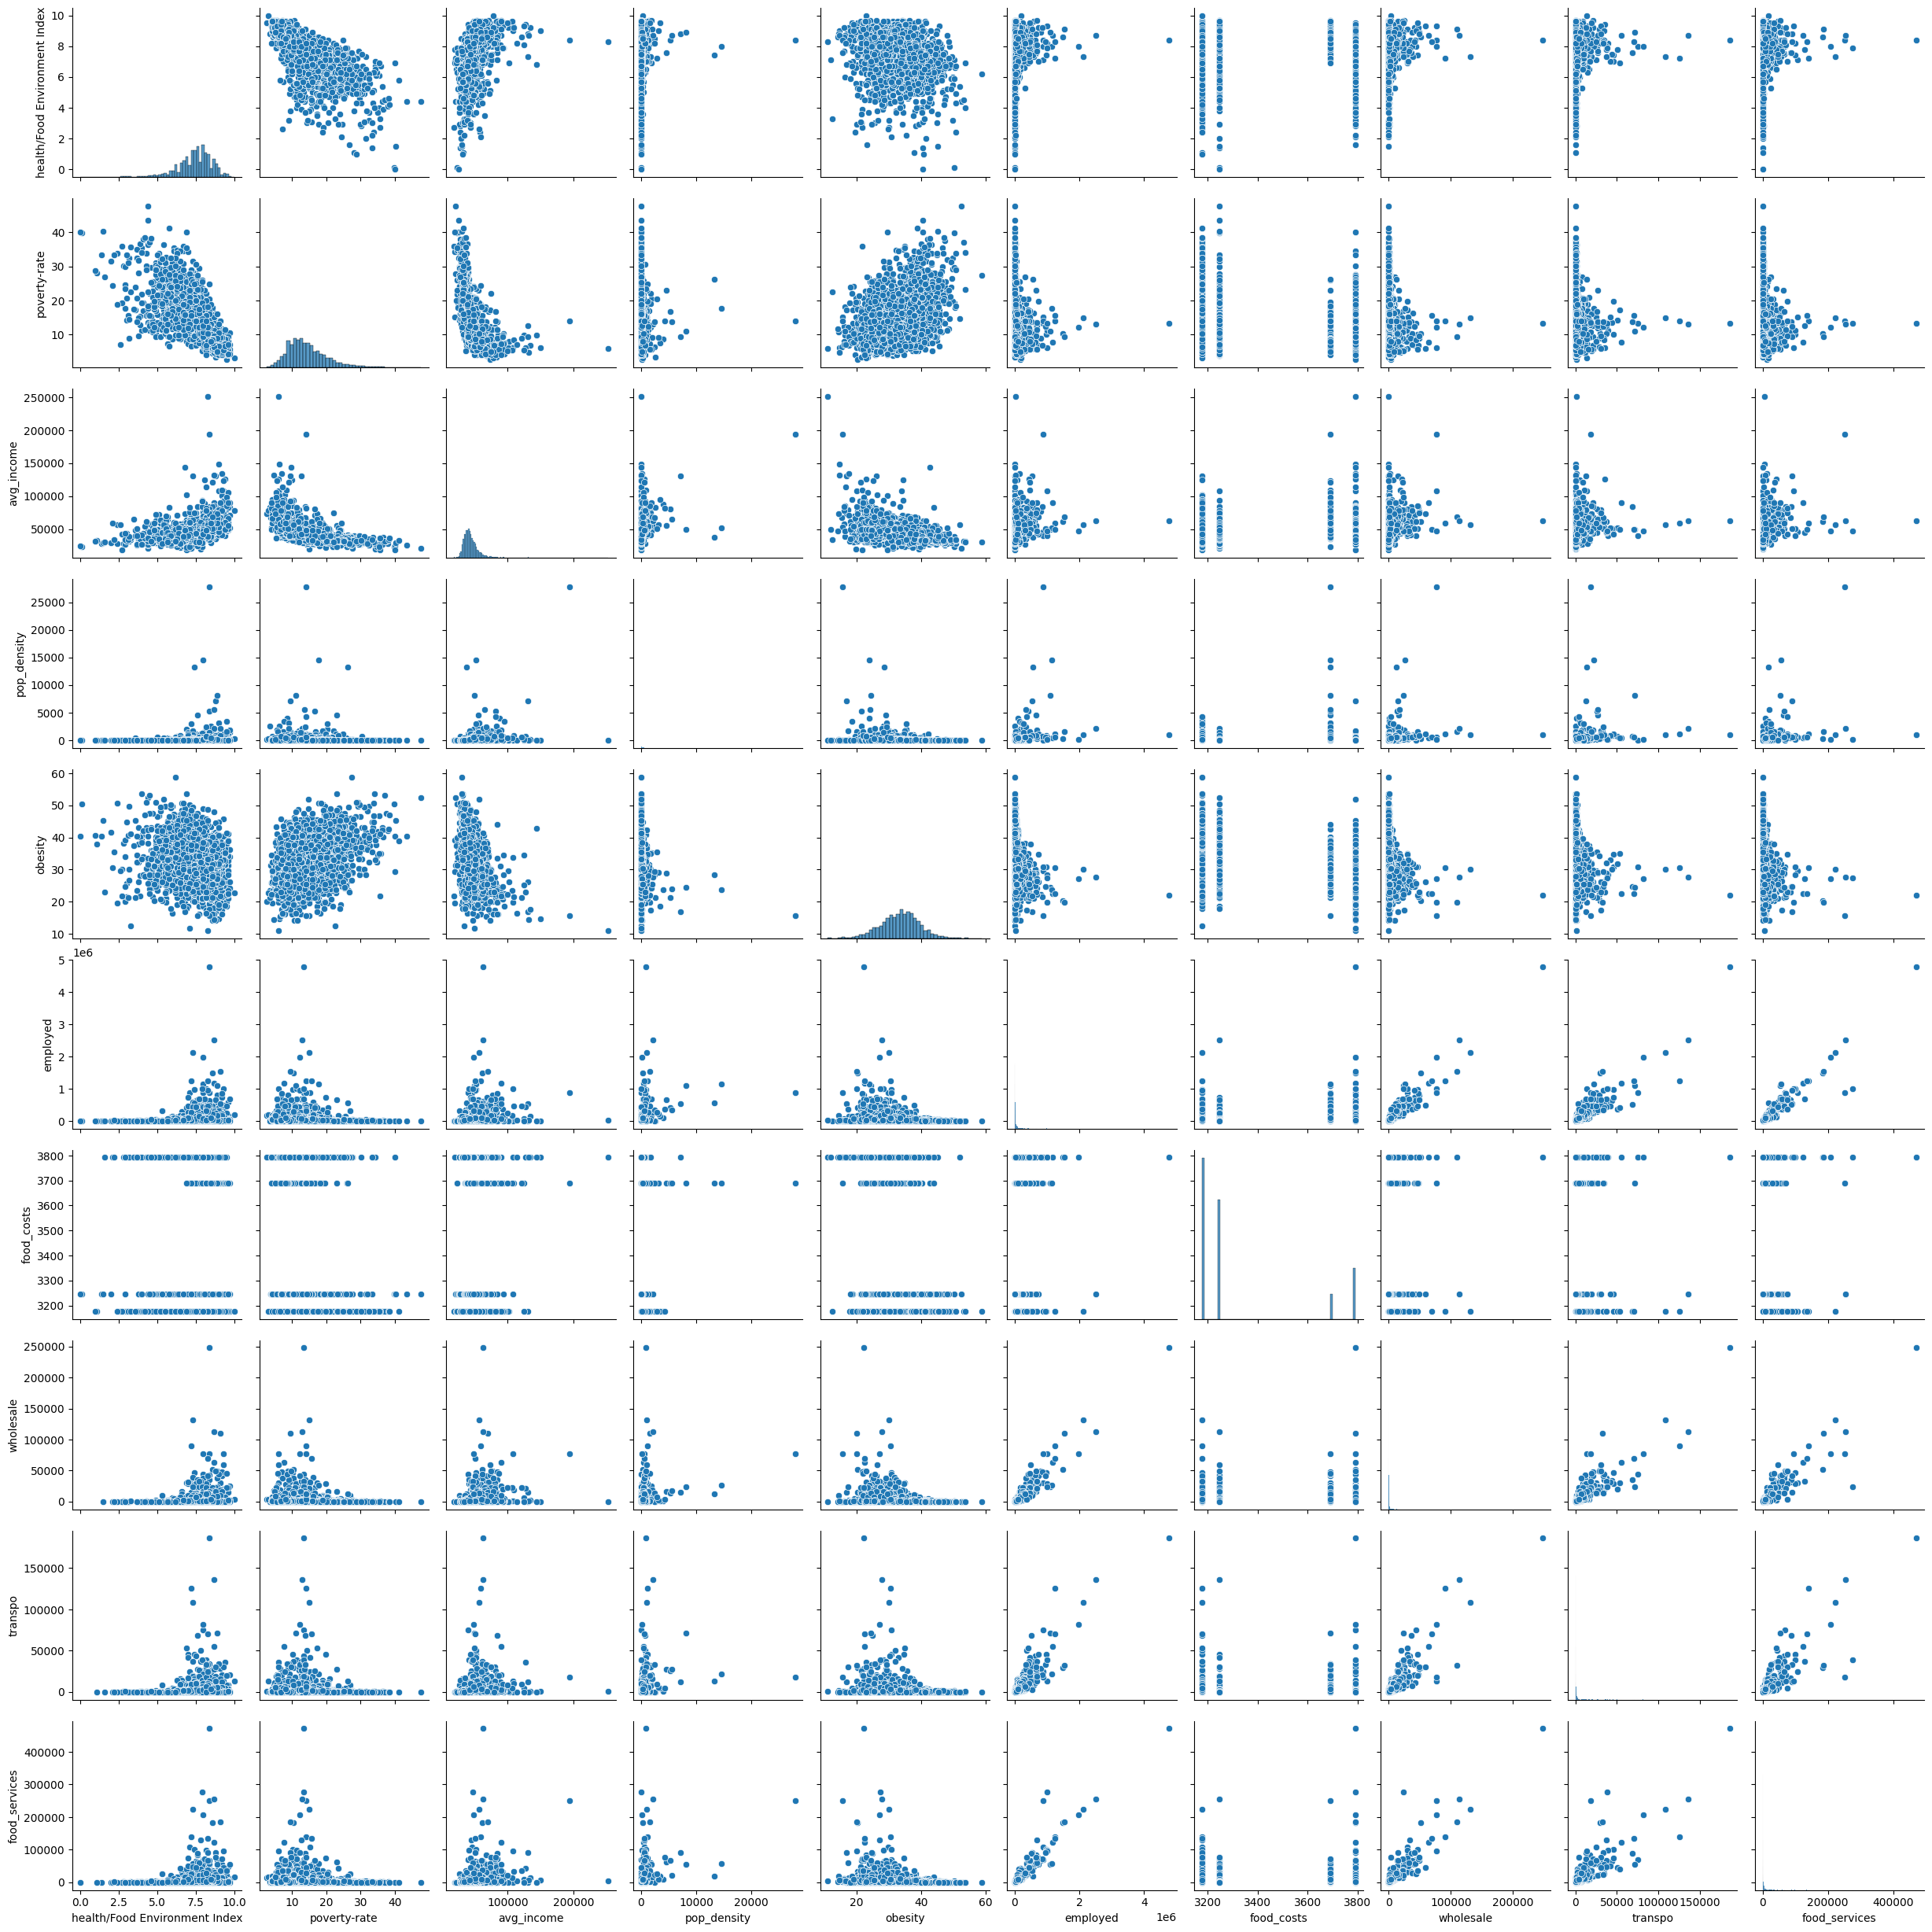

In [ ]:
sns.pairplot(cont)

I'm dropping obesity, employed, and food costs since they look bad. Honestly, the 3 industries I added also look bad, but I'm kind of curious to see how it'll run, so I'm keeping it in.

In [ ]:
cont = cont.drop(columns=["obesity","employed","food_costs"])
print(cont.columns)

Index(['health/Food Environment Index', 'poverty-rate', 'avg_income',
       'pop_density', 'wholesale', 'transpo', 'food_services'],
      dtype='object')


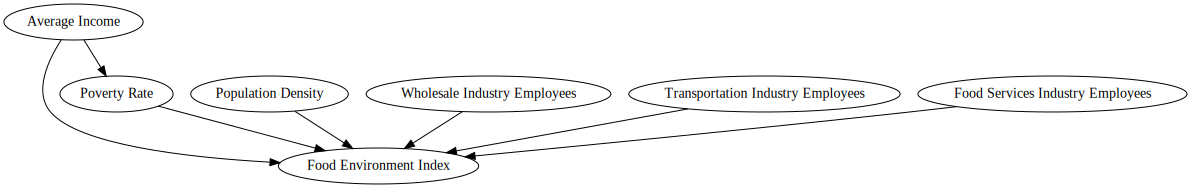

In [ ]:
dag_c = gv.Digraph()

dag_c.node('F','Food Environment Index')
dag_c.node('P','Poverty Rate')
dag_c.node('D','Population Density')
dag_c.node('W','Wholesale Industry Employees')
dag_c.node('T','Transportation Industry Employees')
dag_c.node('S','Food Services Industry Employees')
dag_c.node('I','Average Income')

dag_c.edges(['PF','WF','SF','IP','IF','DF','TF'])
dag_c

In [ ]:
cont = cont.dropna()

In [ ]:
X=cont[["poverty-rate","avg_income","pop_density",'wholesale','transpo','food_services']].to_numpy().reshape(-1,6)
Y=cont["health/Food Environment Index"].to_numpy()

In [ ]:
with pm.Model() as model_cont:
    s = pm.HalfNormal('s',20) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, Y, m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_cont = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_cont, model_cont, extend_inferencedata=True)

<Axes: xlabel='y'>

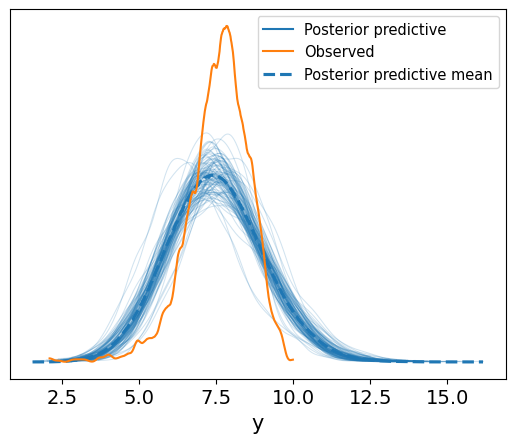

In [ ]:
az.plot_ppc(idata_cont, num_pp_samples=100, colors=["C0","C1","C0"])

That one doesn't look great, so I'm going to try a normal distribution instead.

In [ ]:
with pm.Model() as model_cont_n:
    s = pm.HalfNormal('s',20) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, Y, m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.Normal("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_cont_n = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_cont_n, model_cont_n, extend_inferencedata=True)

<Axes: xlabel='y'>

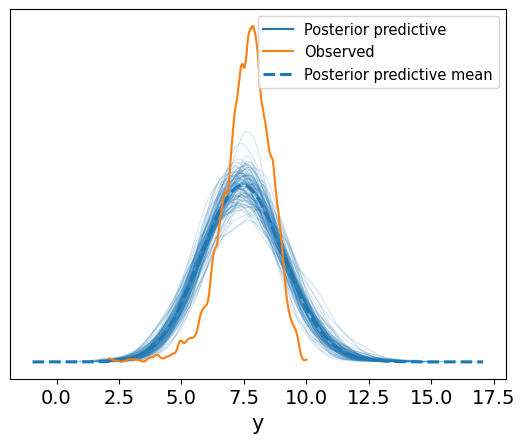

In [ ]:
az.plot_ppc(idata_cont_n, num_pp_samples = 100, colors=["C0","C1","C0"])

In [ ]:
with pm.Model() as model_cont_t:
    s = pm.HalfNormal('s',20) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, Y, m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.StudentT("y",nu=5, mu=μ, sigma=s,  observed=Y) #likelihood, nu is completely arbitrarily chosen
    idata_cont_t = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_cont_t, model_cont_t, extend_inferencedata=True)

<Axes: xlabel='y'>

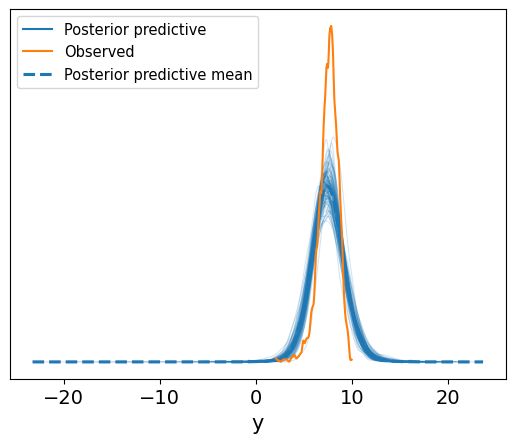

In [ ]:
az.plot_ppc(idata_cont_t, num_pp_samples = 100, colors=["C0","C1","C0"])

ok I'll just go with the normal. With how narrow the student t is being made, it seems like it might have a wider range than the normal without matching the curve any better in other places.

/usr/local/lib/python3.12/dist-packages/pymc_bart/utils.py:494: UserWarning: The grid is smaller than the number of available variables to plot.
                Automatically adjusting the grid size.
  warnings.warn(


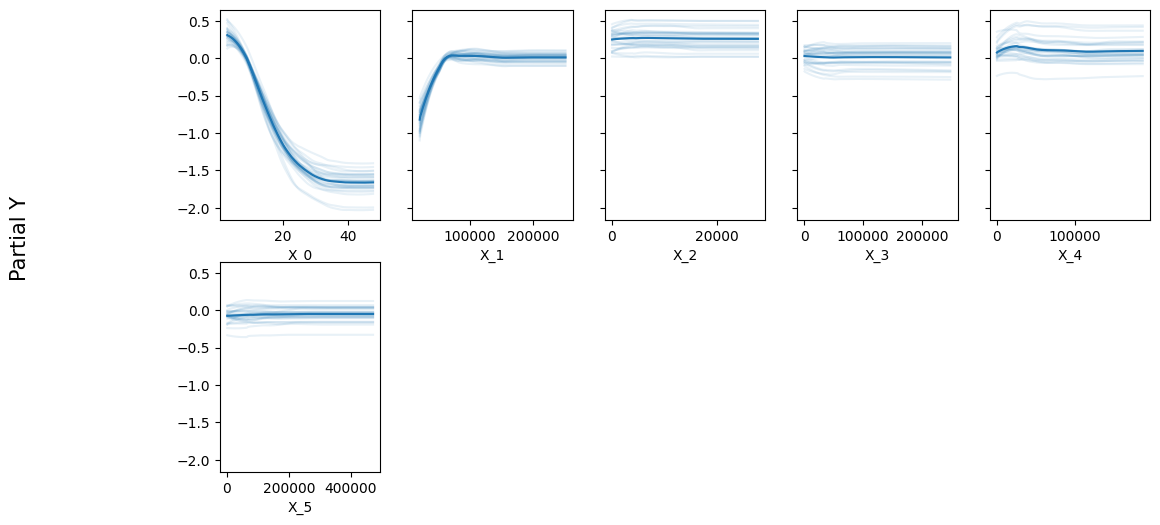

In [ ]:
ax = pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))


In [ ]:
vi_cont = pmb.compute_variable_importance(idata_cont_n, μ_, X)

<Axes: ylabel='R²'>

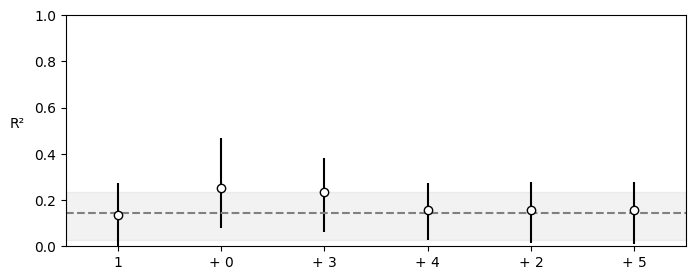

In [ ]:
pmb.plot_variable_importance(vi_cont)

Ok, it doesn't seem there's much correlation between any of these variables, except for poverty rate, which is x_0. The ice plot shows a strong negative correlation whose slope increases the higher the poverty rate. Income, x_1, also seems to have a relatively strong positive correlation with the food environment index at first, but then becomes a straight line. The others seem to show practically no correlation with the y axis.

In teh vi plot, none of these variables seem to contributing a lot to the R^2 value, except x_0 and x_1, which supports the ice plot. Some of these actually seem to be decreasing the R^2 valule, which is kind of sad.

In general, I think I need to abandon all variables that aren't poverty rate and find new variables that have a stronger correlation. I'd like to look at proximity to other cities, proximity to major cities, proximity to interstate highways, etc. The proxies I used for regional farming (precepitation, october temp, latitude) aren't very good proxies either, and I think it'd be good to look at how much counties farm as well, and their proximity to other major farming counties.

I just realized that dividing the number of employees by the population might be a good idea

In [ ]:
contp = cont[["poverty-rate", "health/Food Environment Index", "avg_income", ]]
contp["pop_density"] = counties["population/2016"] / counties["land_area (km^2)"]
contp["transpo_p"] = counties["industry/Transportation and warehousing/employees"] / counties["population/2016"]
contp["wholesale_p"] = counties["industry/Wholesale trade/employees"] / counties["population/2016"]
contp["food_services_p"] = counties["industry/Accommodation and food services/employees"] / counties["population/2016"]


/tmp/ipykernel_22434/3233967622.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  contp["pop_density"] = counties["population/2016"] / counties["land_area (km^2)"]
/tmp/ipykernel_22434/3233967622.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  contp["transpo_p"] = counties["industry/Transportation and warehousing/employees"] / counties["population/2016"]
/tmp/ipykernel_22434/3233967622.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

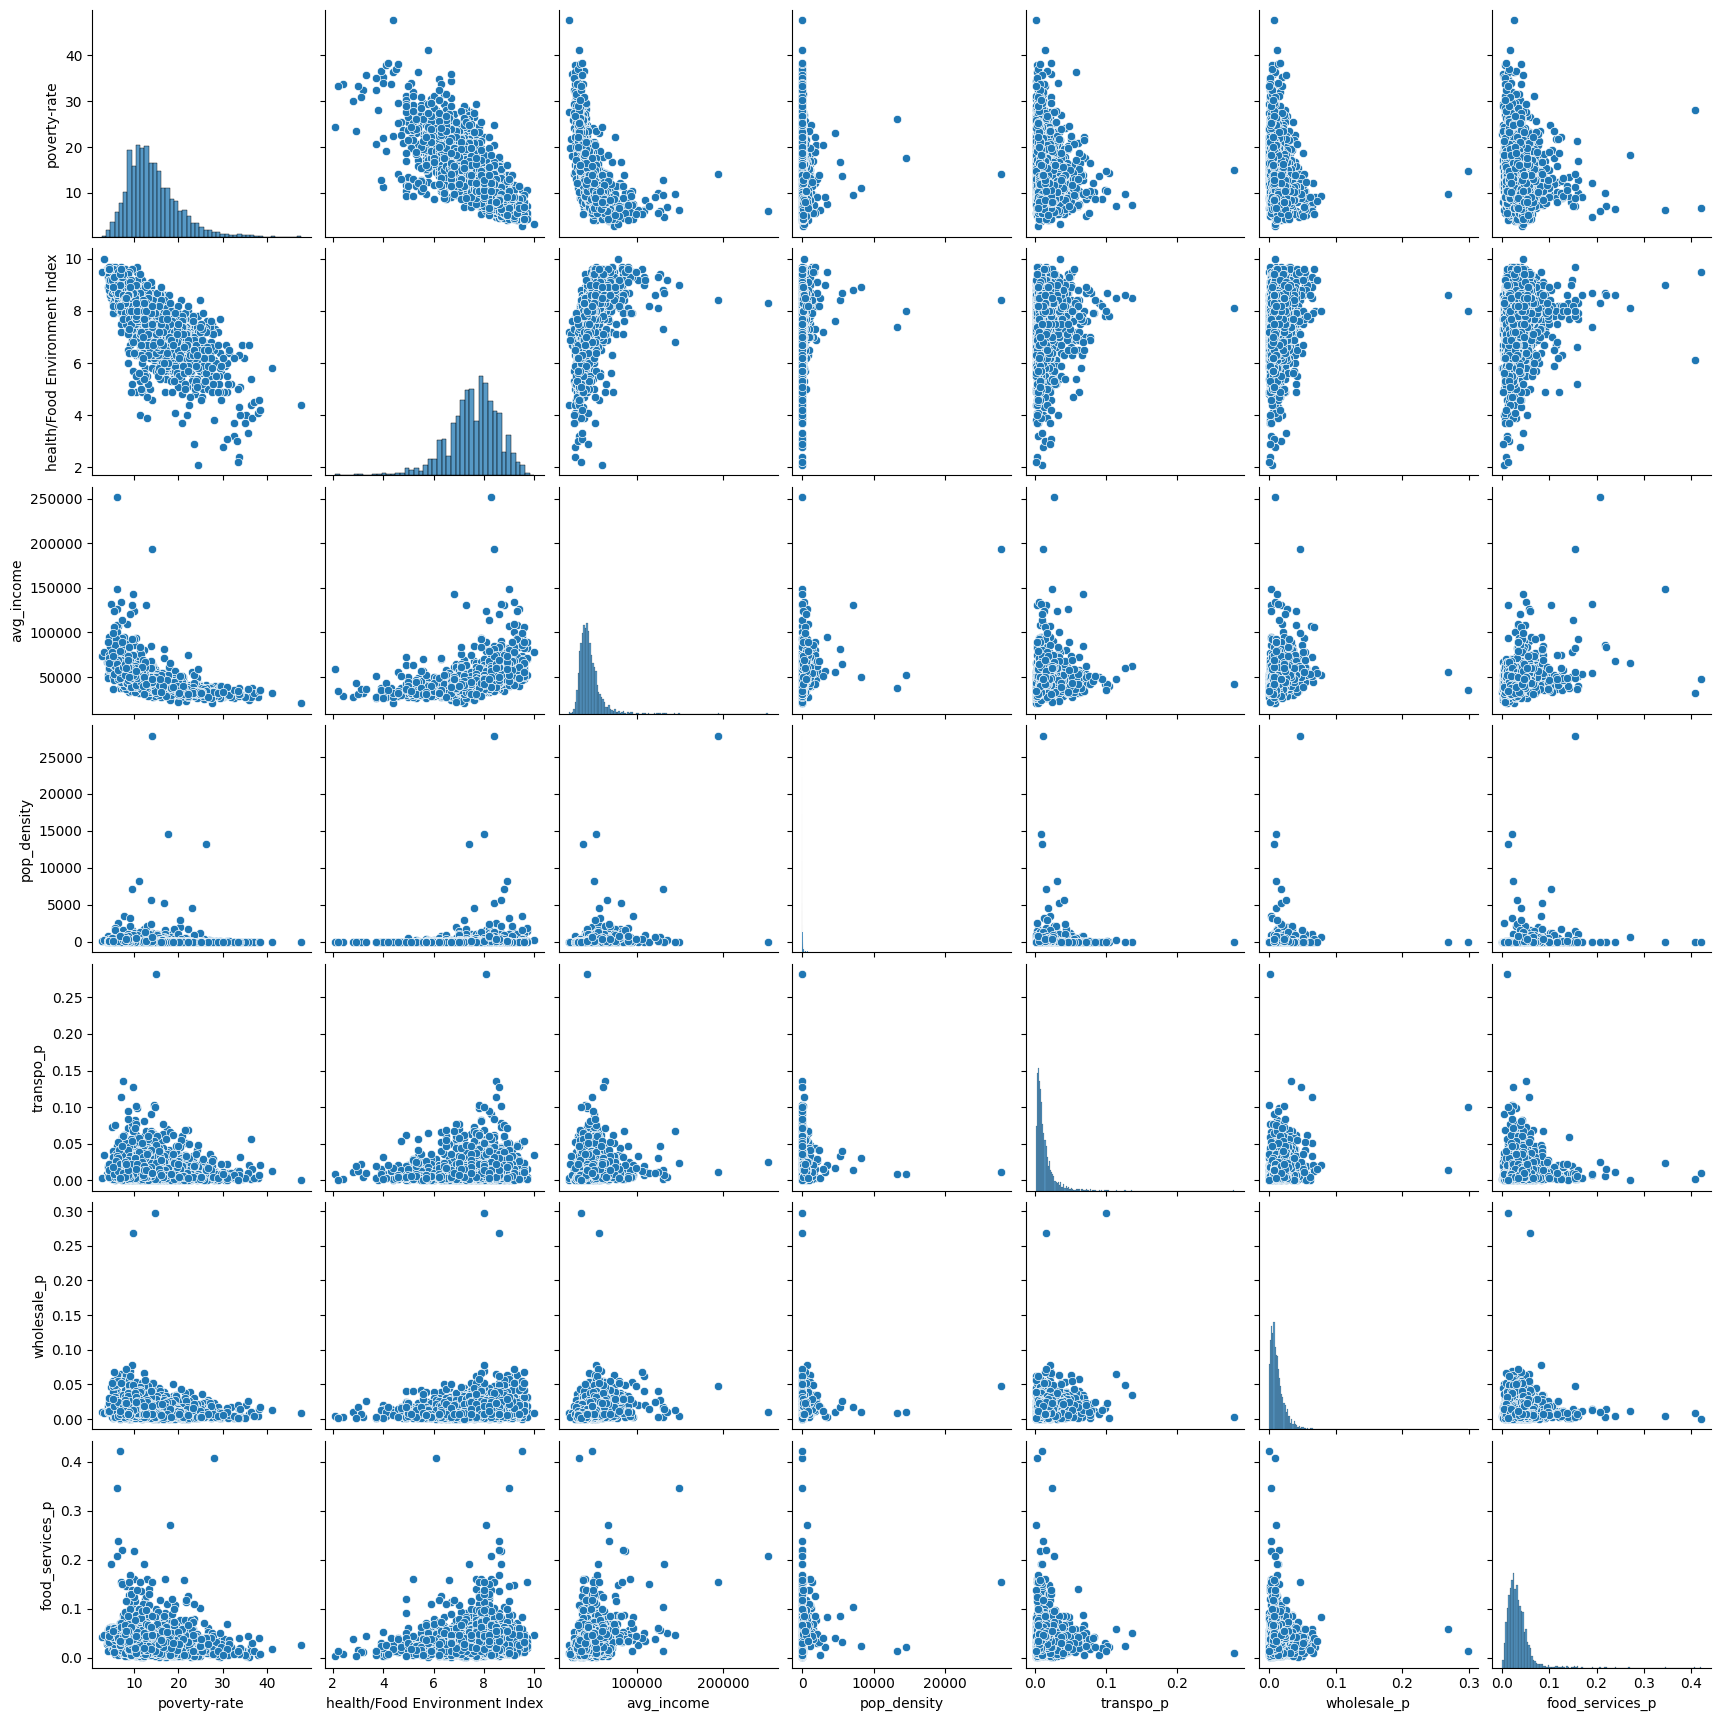

In [ ]:
sns.pairplot(contp)

It doesn't seem to havea strong correlation, so I'm not going to rerun these models.